# Pawar Model — Dataset Exploration, Overfitting Check, Transfer to Our Data (A–F)

### Goals:
1. **Explore** the Pawar (India) dataset — shape, distributions, class balance
2. **Check for overfitting** — training vs validation curves, cross-validation
3. **Preprocess our A–F data** into Pawar-compatible features (stored separately)
4. **Correlation analysis** — how similar are A–F IMU/gyro readings vs India data?
5. **Apply the Pawar model** on our A–F data and **plot predictions on a Leaflet map** (v3-style)


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, gc
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
from scipy import stats
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import folium

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')
print('All libraries loaded.')


PyTorch 2.6.0+cpu | Device: cpu
All libraries loaded.


## 1. Load and Explore the Pawar (India) Dataset

The India_Data has 10 trips of accelerometer data (X, Y, Z) with pothole labels.  
Let's look at the raw data and the windowed features used by the Pawar model.


In [24]:
# ── 1a. Load RAW India data (all 10 trips) ──────────────────────
DATA_ROOT = os.path.join('..', 'India_Data', 'Pathole_Road')

all_dfs = []
for trip_id in range(1, 11):
    path = os.path.join(DATA_ROOT, str(trip_id), 'acceleration_data_with_images.xlsx')
    df = pd.read_excel(path)
    df.columns = ['sno', 'time', 'X', 'Y', 'Z', 'label']
    df['is_pothole'] = (~df['label'].isin(['Not Detected', None]) & df['label'].notna()).astype(int)
    df['trip'] = trip_id
    n_ph = df['is_pothole'].sum()
    print(f'Trip {trip_id:2d}: {len(df):4d} samples | Pothole: {n_ph:3d} | Normal: {len(df)-n_ph:3d}')
    all_dfs.append(df)

raw_india = pd.concat(all_dfs, ignore_index=True)
print(f'\nTotal: {len(raw_india)} samples')
print(f'Pothole: {raw_india["is_pothole"].sum()} ({raw_india["is_pothole"].mean()*100:.1f}%)')
print(f'\nData types:\n{raw_india.dtypes}')
print(f'\nNull counts:\n{raw_india.isnull().sum()}')
print(f'\nAccelerometer stats:')
raw_india[['X', 'Y', 'Z']].describe()


Trip  1:  407 samples | Pothole:   8 | Normal: 399
Trip  2:  399 samples | Pothole:  11 | Normal: 388
Trip  3:  426 samples | Pothole:   7 | Normal: 419
Trip  4:  417 samples | Pothole:  12 | Normal: 405
Trip  5:  399 samples | Pothole:  12 | Normal: 387
Trip  6:  300 samples | Pothole:  18 | Normal: 282
Trip  7:  462 samples | Pothole:   7 | Normal: 455
Trip  8:  347 samples | Pothole:  12 | Normal: 335
Trip  9:  406 samples | Pothole:  14 | Normal: 392
Trip 10:  405 samples | Pothole:  14 | Normal: 391

Total: 3968 samples
Pothole: 115 (2.9%)

Data types:
sno            int64
time          object
X              int64
Y              int64
Z              int64
label         object
is_pothole     int64
trip           int64
dtype: object

Null counts:
sno           0
time          0
X             0
Y             0
Z             0
label         5
is_pothole    0
trip          0
dtype: int64

Accelerometer stats:


,X,Y,Z
count,3968.000000,3968.000000,3968.000000
mean,-16.506048,132.226058,-216.136341
std,98.176264,136.144099,131.855240
min,-512.000000,-512.000000,-512.000000
25%,-63.000000,44.000000,-292.000000
50%,-12.000000,105.000000,-212.500000
75%,38.000000,194.000000,-127.000000
max,511.000000,511.000000,228.000000


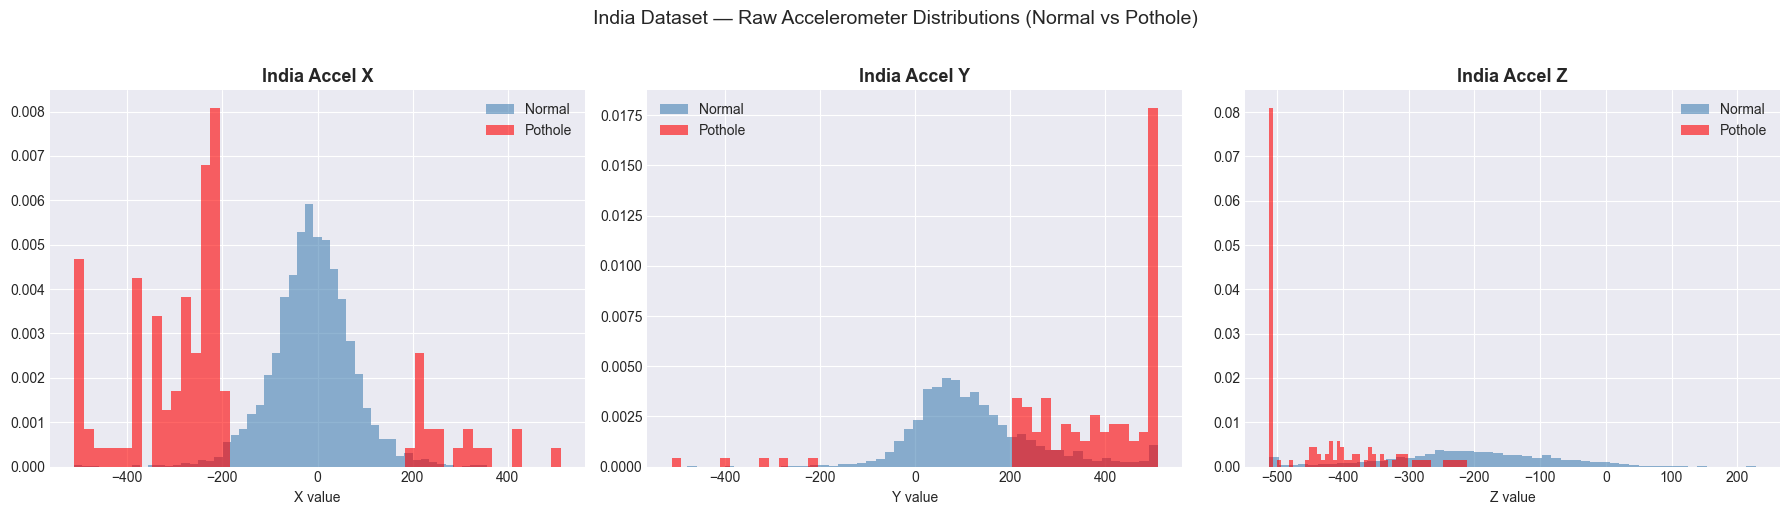

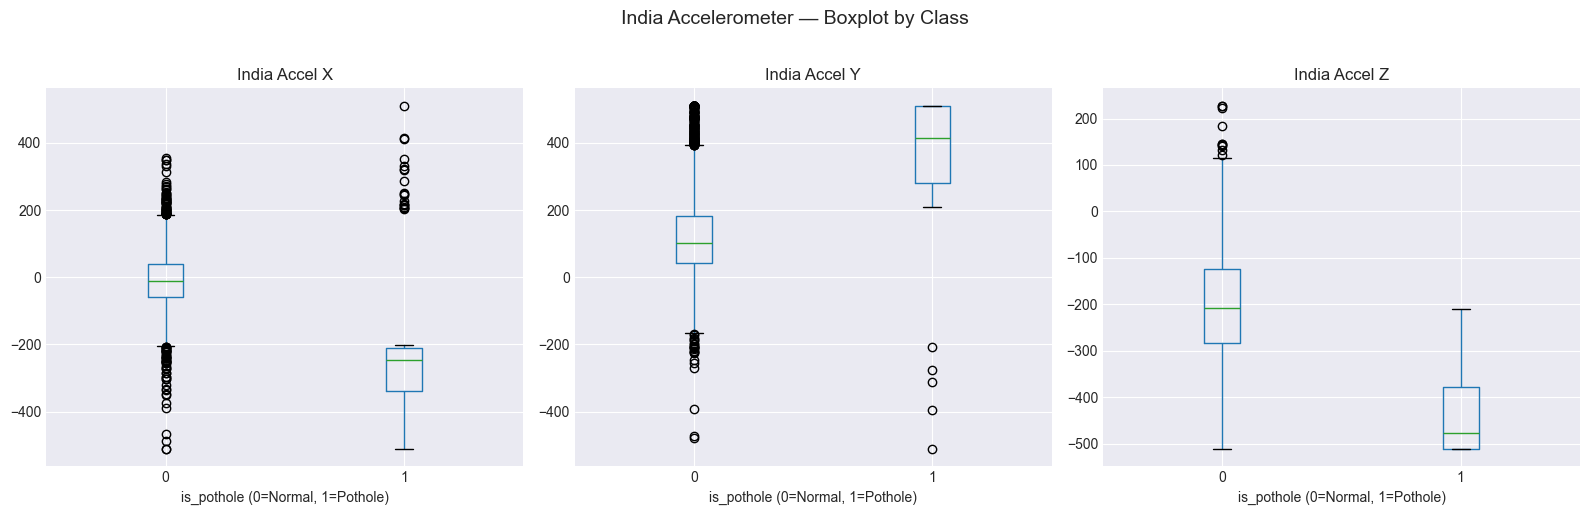

Label distribution:
label
Not Detected                 3848
image_20230302_183559.jpg       1
image_20230302_183607.jpg       1
image_20230302_183613.jpg       1
image_20230302_183615.jpg       1
                             ... 
image_20230302_185729.jpg       1
image_20230302_185731.jpg       1
image_20230302_185733.jpg       1
image_20230302_185737.jpg       1
image_20230302_185739.jpg       1
Name: count, Length: 116, dtype: int64


In [25]:
# ── 1b. Visualize raw India accelerometer data ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color in zip(axes, ['X', 'Y', 'Z'], ['tab:red', 'tab:green', 'tab:blue']):
    raw_india[raw_india['is_pothole']==0][col].hist(bins=50, alpha=0.6, ax=ax, color='steelblue', label='Normal', density=True)
    raw_india[raw_india['is_pothole']==1][col].hist(bins=50, alpha=0.6, ax=ax, color='red', label='Pothole', density=True)
    ax.set_title(f'India Accel {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(f'{col} value')
    ax.legend()
fig.suptitle('India Dataset — Raw Accelerometer Distributions (Normal vs Pothole)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Box plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['X', 'Y', 'Z']):
    raw_india.boxplot(column=col, by='is_pothole', ax=ax)
    ax.set_title(f'India Accel {col}')
    ax.set_xlabel('is_pothole (0=Normal, 1=Pothole)')
fig.suptitle('India Accelerometer — Boxplot by Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Label distribution
print('Label distribution:')
print(raw_india['label'].value_counts())


In [26]:
# ── 1c. Load pre-computed windowed features ─────────────────────
windowed = pd.read_csv('pawar_windowed_features.csv')
print(f'Windowed features shape: {windowed.shape}')
print(f'\nColumns: {list(windowed.columns)}')
print(f'\nClass balance:')
print(f'  Pothole windows: {windowed["is_pothole"].sum()} ({windowed["is_pothole"].mean()*100:.1f}%)')
print(f'  Normal windows:  {(1-windowed["is_pothole"]).sum()} ({(1-windowed["is_pothole"].mean())*100:.1f}%)')
print(f'\nSamples per window (avg): {windowed["n_samples"].mean():.1f}')
print(f'\nWindowed feature stats:')
feature_cols = [c for c in windowed.columns if c.endswith(('_min', '_max', '_mean', '_std'))]
windowed[feature_cols].describe()


Windowed features shape: (217, 20)

Columns: ['X_min', 'X_max', 'X_mean', 'X_std', 'Y_min', 'Y_max', 'Y_mean', 'Y_std', 'Z_min', 'Z_max', 'Z_mean', 'Z_std', 'mag_min', 'mag_max', 'mag_mean', 'mag_std', 'is_pothole', 'n_samples', 'trip', 'window_start']

Class balance:
  Pothole windows: 98 (45.2%)
  Normal windows:  119 (54.8%)

Samples per window (avg): 18.2

Windowed feature stats:


,X_min,X_max,X_mean,X_std,Y_min,Y_max,Y_mean,Y_std,Z_min,Z_max,Z_mean,Z_std,mag_min,mag_max,mag_mean,mag_std
count,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000,217.000000
mean,-228.419355,144.087558,-22.806492,94.812075,-62.400922,425.898618,131.516848,129.370628,-461.419355,-14.562212,-218.632218,124.993368,84.541955,644.761304,294.787928,155.501362
std,113.928073,86.036904,34.522024,37.917788,91.741891,97.704528,38.240233,39.303910,68.556642,82.368285,41.584489,38.597179,56.672130,129.593844,49.737437,47.418269
min,-512.000000,-9.000000,-225.250000,19.374926,-512.000000,136.000000,23.928571,18.811428,-512.000000,-414.000000,-451.750000,12.936806,9.433981,298.882920,180.095071,15.845091
25%,-280.000000,87.000000,-40.433333,68.993647,-92.000000,352.000000,107.750000,103.095112,-512.000000,-54.000000,-240.687500,103.179724,48.052055,557.255776,262.763585,128.764894
50%,-206.000000,133.000000,-20.200000,89.267720,-43.000000,470.000000,131.769231,127.911835,-512.000000,-6.000000,-218.083333,124.954207,69.137544,660.694332,289.347985,153.353231
75%,-148.000000,188.000000,-4.692308,114.868536,-11.000000,511.000000,156.461538,153.856043,-423.000000,29.000000,-194.285714,149.243961,106.681770,733.420752,316.193203,182.807502
max,-37.000000,511.000000,63.100000,294.699086,106.000000,511.000000,274.500000,235.077755,-229.000000,228.000000,-110.166667,236.959568,445.526655,886.233039,613.967844,294.841449


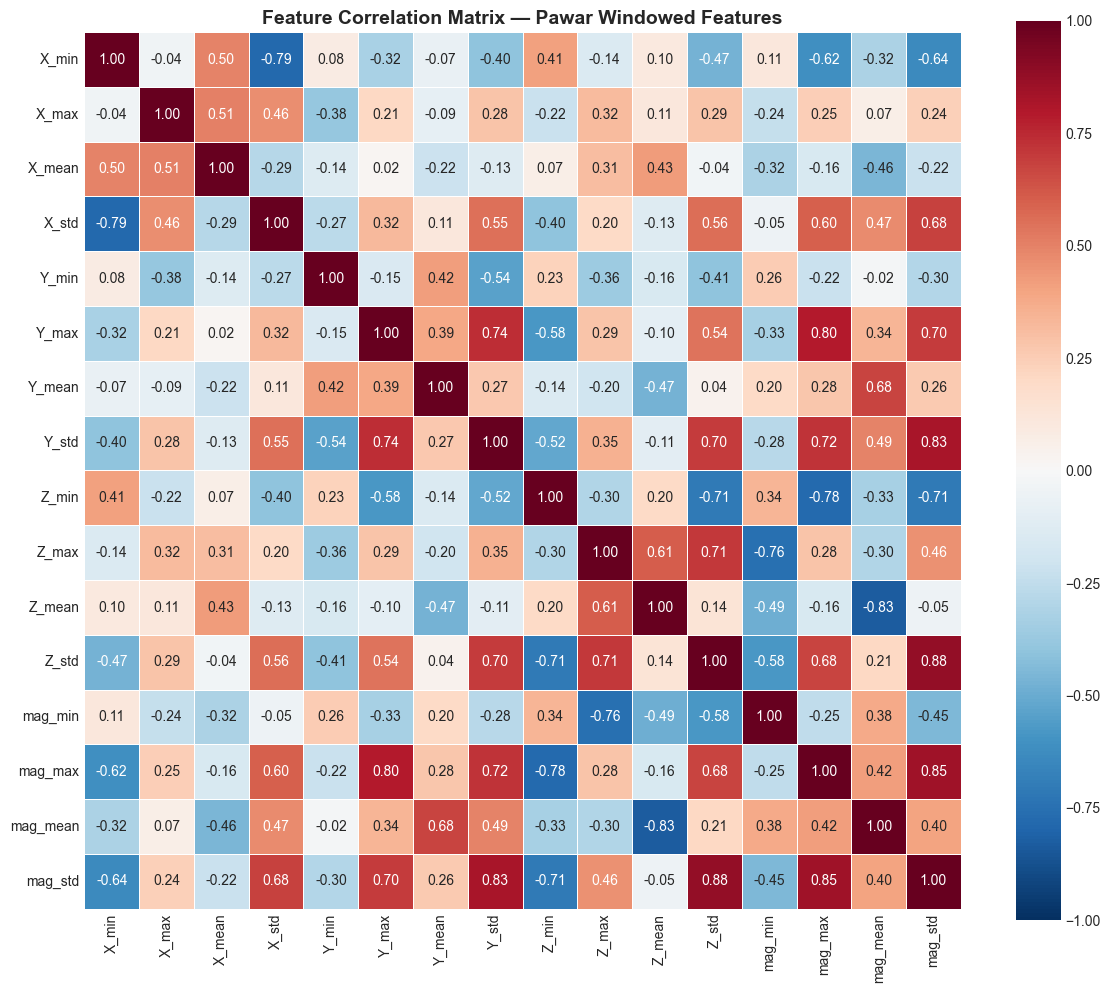

In [27]:
# ── 1d. Feature correlation heatmap (Pawar dataset) ─────────────
corr = windowed[feature_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix — Pawar Windowed Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Train the Pawar Model & Check for Overfitting

We replicate the Pawar ANN (2 hidden layers, dropout, sigmoid output, BCELoss).  
Key checks:
- **Training vs validation curves** — if train acc >> val acc, the model is overfitting
- **Train vs test metrics** — compare precision/recall/F1 on both sets
- **Cross-validation** — K-fold to check stability across splits
- **Early stopping analysis** — at which epoch does val loss start increasing?


In [28]:
# ── 2a. Prepare data (same as original Pawar notebook) ──────────
from imblearn.over_sampling import SMOTE

X = windowed[feature_cols].values
y = windowed['is_pothole'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE on training set
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'Train: {X_train_scaled.shape[0]} ({y_train.sum()} pothole) → SMOTE → {len(y_train_sm)} ({y_train_sm.sum()} pothole)')
print(f'Test:  {X_test_scaled.shape[0]} ({y_test.sum()} pothole)')
print(f'Features: {X_train_scaled.shape[1]}')


Train: 173 (78 pothole) → SMOTE → 190 (95 pothole)
Test:  44 (20 pothole)
Features: 16


In [29]:
# ── 2b. Define the Pawar ANN model ──────────────────────────────
class PawarANN(nn.Module):
    """Pawar et al. ANN: 2 hidden (Dense+Dropout) + sigmoid output."""
    def __init__(self, n_features, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(32, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

# ── 2c. Train with FULL history tracking ────────────────────────
EPOCHS = 140
BATCH_SIZE = 3

n_features = X_train_scaled.shape[1]
model = PawarANN(n_features).to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

X_tr_t = torch.FloatTensor(X_train_sm).to(device)
y_tr_t = torch.FloatTensor(y_train_sm).to(device)
X_te_t = torch.FloatTensor(X_test_scaled).to(device)
y_te_t = torch.FloatTensor(y_test).to(device)

# Also evaluate on training set WITHOUT SMOTE to see true train performance
X_train_orig_t = torch.FloatTensor(X_train_scaled).to(device)
y_train_orig_t = torch.FloatTensor(y_train).to(device)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': [],
           'train_orig_loss': [], 'train_orig_acc': []}

for epoch in range(EPOCHS):
    model.train()
    epoch_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
        correct += ((pred >= 0.5).float() == yb).sum().item()
        total += len(yb)
    
    history['loss'].append(epoch_loss / total)
    history['accuracy'].append(correct / total)
    
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        val_pred = model(X_te_t)
        val_loss = criterion(val_pred, y_te_t).item()
        val_acc = ((val_pred >= 0.5).float() == y_te_t).sum().item() / len(y_te_t)
        
        # Evaluate on original (non-SMOTE) train set
        train_orig_pred = model(X_train_orig_t)
        train_orig_loss = criterion(train_orig_pred, y_train_orig_t).item()
        train_orig_acc = ((train_orig_pred >= 0.5).float() == y_train_orig_t).sum().item() / len(y_train_orig_t)
    
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)
    history['train_orig_loss'].append(train_orig_loss)
    history['train_orig_acc'].append(train_orig_acc)

print(f'\nTraining complete ({EPOCHS} epochs)')
print(f'Final SMOTE train acc: {history["accuracy"][-1]:.4f} | loss: {history["loss"][-1]:.4f}')
print(f'Final real train acc:  {history["train_orig_acc"][-1]:.4f} | loss: {history["train_orig_loss"][-1]:.4f}')
print(f'Final test acc:        {history["val_accuracy"][-1]:.4f} | loss: {history["val_loss"][-1]:.4f}')


PawarANN(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Parameters: 3,201

Training complete (140 epochs)
Final SMOTE train acc: 0.9579 | loss: 0.0768
Final real train acc:  0.9884 | loss: 0.0210
Final test acc:        0.9545 | loss: 0.1679


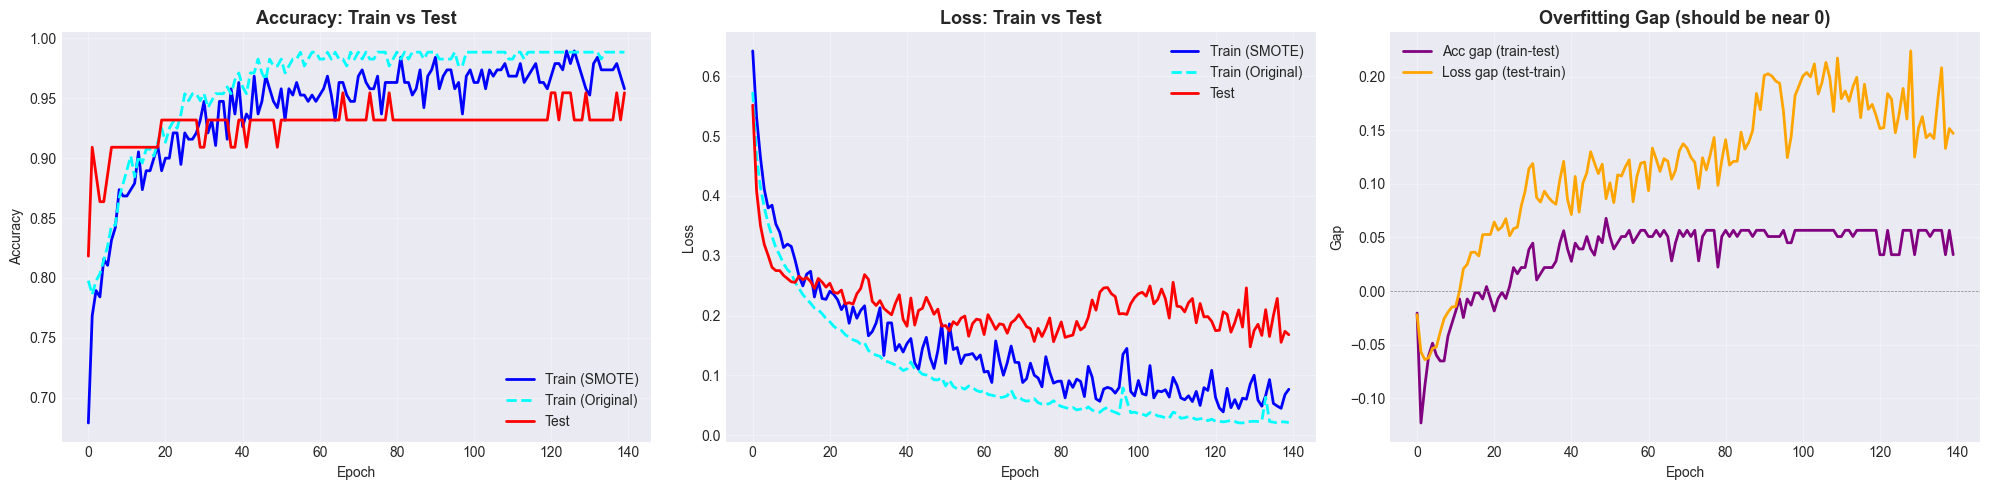


🔍 OVERFITTING DIAGNOSIS:
  Best validation loss at epoch 130: 0.1477
  Final validation loss at epoch 140: 0.1679
  Train-test accuracy gap (final): 0.0339
  Train-test loss gap (final): 0.1469
  ✅ NO SIGNIFICANT OVERFITTING — gap is only 3.4%
  ✅ Val loss stable — no premature early stopping needed


In [30]:
# ── 2d. OVERFITTING ANALYSIS — Training vs Validation Curves ────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Accuracy curves
ax = axes[0]
ax.plot(history['accuracy'], label='Train (SMOTE)', lw=2, color='blue')
ax.plot(history['train_orig_acc'], label='Train (Original)', lw=2, color='cyan', ls='--')
ax.plot(history['val_accuracy'], label='Test', lw=2, color='red')
ax.set_title('Accuracy: Train vs Test', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

# Loss curves
ax = axes[1]
ax.plot(history['loss'], label='Train (SMOTE)', lw=2, color='blue')
ax.plot(history['train_orig_loss'], label='Train (Original)', lw=2, color='cyan', ls='--')
ax.plot(history['val_loss'], label='Test', lw=2, color='red')
ax.set_title('Loss: Train vs Test', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# Gap analysis (overfitting indicator)
ax = axes[2]
gap_acc = np.array(history['train_orig_acc']) - np.array(history['val_accuracy'])
gap_loss = np.array(history['val_loss']) - np.array(history['train_orig_loss'])
ax.plot(gap_acc, label='Acc gap (train-test)', lw=2, color='purple')
ax.plot(gap_loss, label='Loss gap (test-train)', lw=2, color='orange')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_title('Overfitting Gap (should be near 0)', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Gap')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Early stopping analysis
val_losses = history['val_loss']
best_epoch = np.argmin(val_losses)
print(f'\n🔍 OVERFITTING DIAGNOSIS:')
print(f'  Best validation loss at epoch {best_epoch+1}: {val_losses[best_epoch]:.4f}')
print(f'  Final validation loss at epoch {EPOCHS}: {val_losses[-1]:.4f}')
print(f'  Train-test accuracy gap (final): {gap_acc[-1]:.4f}')
print(f'  Train-test loss gap (final): {gap_loss[-1]:.4f}')

if gap_acc[-1] > 0.10:
    print(f'  ⚠️ OVERFITTING DETECTED — train acc exceeds test acc by {gap_acc[-1]:.1%}')
elif gap_acc[-1] > 0.05:
    print(f'  ⚠️ MILD OVERFITTING — train acc exceeds test acc by {gap_acc[-1]:.1%}')
else:
    print(f'  ✅ NO SIGNIFICANT OVERFITTING — gap is only {gap_acc[-1]:.1%}')

if val_losses[-1] > val_losses[best_epoch] * 1.15:
    print(f'  ⚠️ Val loss increased {((val_losses[-1]/val_losses[best_epoch])-1)*100:.1f}% from best → model trains too long')
    print(f'  → Ideal early stopping at epoch {best_epoch+1}')
else:
    print(f'  ✅ Val loss stable — no premature early stopping needed')


════════════════════════════════════════════════════════════
TRAIN vs TEST METRICS — Overfitting Check
════════════════════════════════════════════════════════════

TRAIN Set:
  Accuracy:  0.9884
  Precision: 1.0000
  Recall:    0.9744
  F1 Score:  0.9870

TEST Set:
  Accuracy:  0.9545
  Precision: 1.0000
  Recall:    0.9000
  F1 Score:  0.9474


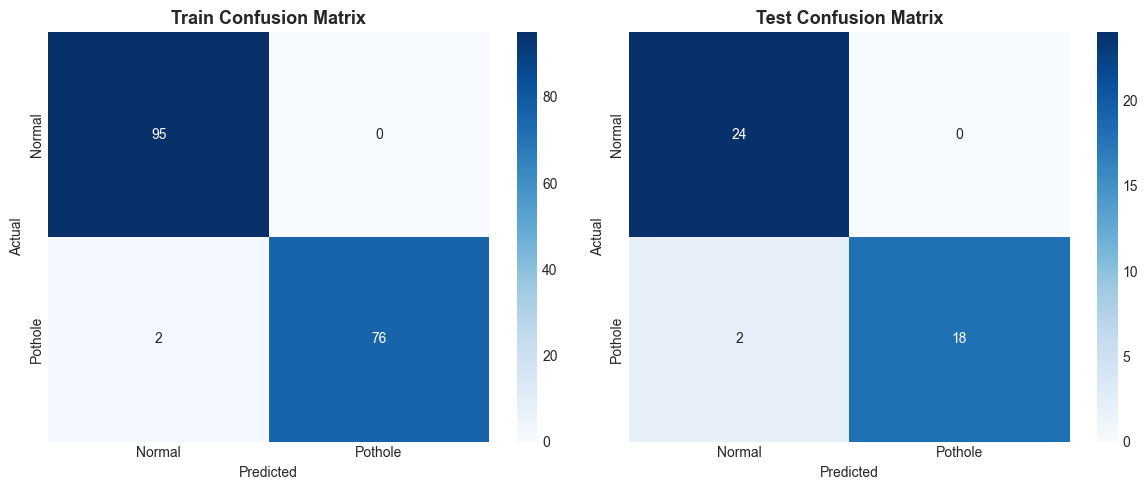

In [31]:
# ── 2e. Train vs Test metrics (detailed) ────────────────────────
model.eval()
with torch.no_grad():
    # Test predictions
    y_test_prob = model(X_te_t).cpu().numpy()
    y_test_pred = (y_test_prob >= 0.5).astype(int)
    
    # Train predictions (on original, non-SMOTE data)
    y_train_prob = model(X_train_orig_t).cpu().numpy()
    y_train_pred = (y_train_prob >= 0.5).astype(int)

print('═' * 60)
print('TRAIN vs TEST METRICS — Overfitting Check')
print('═' * 60)
for name, y_true, y_pred in [('TRAIN', y_train, y_train_pred), ('TEST', y_test, y_test_pred)]:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f'\n{name} Set:')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1 Score:  {f1:.4f}')

# Confusion matrices side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_true, y_pred, title in [(ax1, y_train, y_train_pred, 'Train'), (ax2, y_test, y_test_pred, 'Test')]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Pothole'], yticklabels=['Normal','Pothole'])
    ax.set_title(f'{title} Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


In [32]:
# ── 2f. Cross-Validation (5-fold) for robustness ────────────────
from sklearn.neural_network import MLPClassifier

# Use sklearn MLP as a quick proxy for K-fold CV (PyTorch doesn't have built-in CV)
mlp_cv = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                       max_iter=140, batch_size=3, random_state=42, early_stopping=False)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(mlp_cv, X_train_scaled, y_train, cv=skf, scoring='f1')

print('5-Fold Cross-Validation (sklearn MLP proxy):')
print(f'  F1 scores: {cv_scores}')
print(f'  Mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

if cv_scores.std() > 0.10:
    print(f'  ⚠️ HIGH VARIANCE — model performance varies a lot across folds (std={cv_scores.std():.3f})')
else:
    print(f'  ✅ STABLE — consistent performance across folds')

# Also check CV accuracy
cv_acc = cross_val_score(mlp_cv, X_train_scaled, y_train, cv=skf, scoring='accuracy')
print(f'\n  CV Accuracy: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  Train accuracy (from PyTorch): {history["train_orig_acc"][-1]:.4f}')
print(f'  Gap: {history["train_orig_acc"][-1] - cv_acc.mean():.4f}')


5-Fold Cross-Validation (sklearn MLP proxy):
  F1 scores: [0.73333333 0.7027027  0.84848485 0.8        0.96551724]
  Mean F1: 0.8100 ± 0.0929
  ✅ STABLE — consistent performance across folds

  CV Accuracy: 0.8217 ± 0.0943
  Train accuracy (from PyTorch): 0.9884
  Gap: 0.1668


## 3. Preprocess Our A–F Data into Pawar-Compatible Features

**Key challenge:** Our data has different format than India data:
- Our data: Accelerometer.csv (x, y, z in m/s²), Gyroscope.csv, TotalAcceleration.csv, Location.csv
- India data: acceleration_data_with_images.xlsx (X, Y, Z in raw sensor units, no gyro)

**Our approach:**
1. Load Accelerometer data for routes A–F
2. Create 2-second sliding windows (same as Pawar)
3. Extract min/max/mean/std for each axis + magnitude = 16 features
4. Apply the same Z-score scaler (fitted on India data)
5. Save preprocessed data to `pawar/preprocessed/` (originals untouched)


In [33]:
# ── 3a. Load our A–F accelerometer + location data ──────────────
DATA_ROOT_OUR = os.path.join('..', '')
folders = ['A', 'B', 'C', 'D', 'E', 'F']

our_data = {}
for folder in folders:
    base = os.path.join(DATA_ROOT_OUR, folder)
    accel = pd.read_csv(os.path.join(base, 'Accelerometer.csv'))
    total = pd.read_csv(os.path.join(base, 'TotalAcceleration.csv'))
    loc = pd.read_csv(os.path.join(base, 'Location.csv'))
    gyro = pd.read_csv(os.path.join(base, 'Gyroscope.csv'))
    our_data[folder] = {'accel': accel, 'total': total, 'location': loc, 'gyro': gyro}
    print(f'Route {folder}: accel={len(accel):,}  total={len(total):,}  gyro={len(gyro):,}  loc={len(loc):,}')

print('\nOur data columns:')
print(f'  Accelerometer: {list(our_data["A"]["accel"].columns)}')
print(f'  TotalAccel:    {list(our_data["A"]["total"].columns)}')
print(f'  Gyroscope:     {list(our_data["A"]["gyro"].columns)}')
print(f'  Location:      {list(our_data["A"]["location"].columns)}')


Route A: accel=13,249  total=13,246  gyro=13,255  loc=138
Route B: accel=31,524  total=31,532  gyro=31,531  loc=327
Route C: accel=12,108  total=12,111  gyro=12,108  loc=126
Route D: accel=34,020  total=34,020  gyro=34,022  loc=353
Route E: accel=38,632  total=38,631  gyro=38,639  loc=400
Route F: accel=19,897  total=19,899  gyro=19,898  loc=206

Our data columns:
  Accelerometer: ['time', 'seconds_elapsed', 'z', 'y', 'x']
  TotalAccel:    ['time', 'seconds_elapsed', 'z', 'y', 'x']
  Gyroscope:     ['time', 'seconds_elapsed', 'z', 'y', 'x']
  Location:      ['time', 'seconds_elapsed', 'bearingAccuracy', 'speedAccuracy', 'verticalAccuracy', 'horizontalAccuracy', 'speed', 'bearing', 'altitude', 'longitude', 'latitude']


In [34]:
# ── 3b. Create 2-second windows from our accelerometer data ─────
WINDOW_SEC = 2  # Same as Pawar

def create_windows_our(accel_df, total_df, loc_df, route_name, window_sec=WINDOW_SEC):
    """
    Create Pawar-style 2-second windows from our accelerometer data.
    Uses TotalAcceleration (which includes gravity) as the primary signal,
    matching how the India data works (their accel includes gravity component).
    Also maps each window to GPS coordinates.
    """
    t = total_df['seconds_elapsed'].values
    max_t = t[-1]
    
    # Precompute GPS interpolation arrays
    loc_t = loc_df['seconds_elapsed'].values.astype('float64')
    loc_lat = loc_df['latitude'].values.astype('float64')
    loc_lon = loc_df['longitude'].values.astype('float64')
    loc_speed = loc_df['speed'].values.astype('float64') if 'speed' in loc_df.columns else np.zeros(len(loc_df))
    
    windows = []
    t_start = t[0]
    
    while t_start + window_sec <= max_t + 1:
        mask = (t >= t_start) & (t < t_start + window_sec)
        w = total_df[mask]
        
        if len(w) < 3:
            t_start += window_sec
            continue
        
        row = {}
        # X, Y, Z from TotalAcceleration (includes gravity, like India data)
        for axis in ['x', 'y', 'z']:
            vals = w[axis].values.astype(float)
            row[f'{axis.upper()}_min'] = vals.min()
            row[f'{axis.upper()}_max'] = vals.max()
            row[f'{axis.upper()}_mean'] = vals.mean()
            row[f'{axis.upper()}_std'] = vals.std() if len(vals) > 1 else 0.0
        
        # Magnitude
        mag = np.sqrt(w['x'].values**2 + w['y'].values**2 + w['z'].values**2)
        row['mag_min'] = float(mag.min())
        row['mag_max'] = float(mag.max())
        row['mag_mean'] = float(mag.mean())
        row['mag_std'] = float(mag.std()) if len(mag) > 1 else 0.0
        
        # GPS coordinates (interpolate to window midpoint)
        mid_t = t_start + window_sec / 2
        row['latitude'] = float(np.interp(mid_t, loc_t, loc_lat))
        row['longitude'] = float(np.interp(mid_t, loc_t, loc_lon))
        row['speed'] = float(np.interp(mid_t, loc_t, loc_speed))
        
        row['n_samples'] = len(w)
        row['route'] = route_name
        row['window_start'] = t_start
        
        windows.append(row)
        t_start += window_sec
    
    return pd.DataFrame(windows)


# Process all routes
our_windows = {}
all_our_windows = []
for folder in folders:
    d = our_data[folder]
    w = create_windows_our(d['accel'], d['total'], d['location'], folder)
    our_windows[folder] = w
    all_our_windows.append(w)
    print(f'Route {folder}: {len(w)} windows | Avg samples/window: {w["n_samples"].mean():.1f}')

our_all_windowed = pd.concat(all_our_windows, ignore_index=True)
print(f'\nTotal windows (all routes): {len(our_all_windowed)}')
print(f'\nOur windowed feature columns:')
our_feature_cols = [c for c in our_all_windowed.columns if c.endswith(('_min', '_max', '_mean', '_std'))]
print(our_feature_cols)


Route A: 69 windows | Avg samples/window: 192.0
Route B: 163 windows | Avg samples/window: 192.9
Route C: 63 windows | Avg samples/window: 192.2
Route D: 176 windows | Avg samples/window: 193.0
Route E: 200 windows | Avg samples/window: 192.9
Route F: 103 windows | Avg samples/window: 193.0

Total windows (all routes): 774

Our windowed feature columns:
['X_min', 'X_max', 'X_mean', 'X_std', 'Y_min', 'Y_max', 'Y_mean', 'Y_std', 'Z_min', 'Z_max', 'Z_mean', 'Z_std', 'mag_min', 'mag_max', 'mag_mean', 'mag_std']


In [35]:
# ── 3c. Save preprocessed data (DO NOT modify originals) ────────
preproc_dir = os.path.join('.', 'preprocessed')
os.makedirs(preproc_dir, exist_ok=True)

for folder in folders:
    w = our_windows[folder]
    out_path = os.path.join(preproc_dir, f'route_{folder}_windowed.csv')
    w.to_csv(out_path, index=False)
    print(f'Saved → {out_path} ({len(w)} windows)')

# Also save the combined file
combined_path = os.path.join(preproc_dir, 'all_routes_windowed.csv')
our_all_windowed.to_csv(combined_path, index=False)
print(f'\nSaved combined → {combined_path} ({len(our_all_windowed)} windows)')
print(f'\n✅ Original files untouched. All preprocessed data in pawar/preprocessed/')


Saved → .\preprocessed\route_A_windowed.csv (69 windows)
Saved → .\preprocessed\route_B_windowed.csv (163 windows)
Saved → .\preprocessed\route_C_windowed.csv (63 windows)
Saved → .\preprocessed\route_D_windowed.csv (176 windows)
Saved → .\preprocessed\route_E_windowed.csv (200 windows)
Saved → .\preprocessed\route_F_windowed.csv (103 windows)

Saved combined → .\preprocessed\all_routes_windowed.csv (774 windows)

✅ Original files untouched. All preprocessed data in pawar/preprocessed/


## 4. Correlation Analysis — Our A–F Data vs India Data

Both datasets are **IMU data** (accelerometer readings from smartphones).  
Key question: How similar are the distributions? If they're close, the Pawar model should transfer well.

We compare:
1. **Matching feature distributions** (histograms overlay)
2. **Statistical similarity** (KS test, mean/std comparison)
3. **Correlation matrices** side by side
4. **Domain gap quantification**

**Note:** India data has different units (raw ADC values ~[-512, 511]) vs our data (m/s² ~[-5, 15]).  
We compare **after Z-score normalization** (which is what the model sees).


In [36]:
# ── 4a. Align feature columns between India and our data ────────
# India windowed features use: X_min, X_max, X_mean, X_std, Y_*, Z_*, mag_*
# Our data uses the same naming (uppercase) from create_windows_our()

# Both have these 16 features:
india_features = windowed[feature_cols].copy()
our_features = our_all_windowed[our_feature_cols].copy()

print(f'India features shape: {india_features.shape}')
print(f'Our features shape:   {our_features.shape}')
print(f'\nIndia feature columns: {feature_cols}')
print(f'Our feature columns:   {our_feature_cols}')

# Make sure they match (India uses X_min, our uses X_min too)
# Verify alignment
for i, (ic, oc) in enumerate(zip(feature_cols, our_feature_cols)):
    match = '✅' if ic == oc else '❌'
    print(f'  {match} {ic:15s} ↔ {oc}')


India features shape: (217, 16)
Our features shape:   (774, 16)

India feature columns: ['X_min', 'X_max', 'X_mean', 'X_std', 'Y_min', 'Y_max', 'Y_mean', 'Y_std', 'Z_min', 'Z_max', 'Z_mean', 'Z_std', 'mag_min', 'mag_max', 'mag_mean', 'mag_std']
Our feature columns:   ['X_min', 'X_max', 'X_mean', 'X_std', 'Y_min', 'Y_max', 'Y_mean', 'Y_std', 'Z_min', 'Z_max', 'Z_mean', 'Z_std', 'mag_min', 'mag_max', 'mag_mean', 'mag_std']
  ✅ X_min           ↔ X_min
  ✅ X_max           ↔ X_max
  ✅ X_mean          ↔ X_mean
  ✅ X_std           ↔ X_std
  ✅ Y_min           ↔ Y_min
  ✅ Y_max           ↔ Y_max
  ✅ Y_mean          ↔ Y_mean
  ✅ Y_std           ↔ Y_std
  ✅ Z_min           ↔ Z_min
  ✅ Z_max           ↔ Z_max
  ✅ Z_mean          ↔ Z_mean
  ✅ Z_std           ↔ Z_std
  ✅ mag_min         ↔ mag_min
  ✅ mag_max         ↔ mag_max
  ✅ mag_mean        ↔ mag_mean
  ✅ mag_std         ↔ mag_std


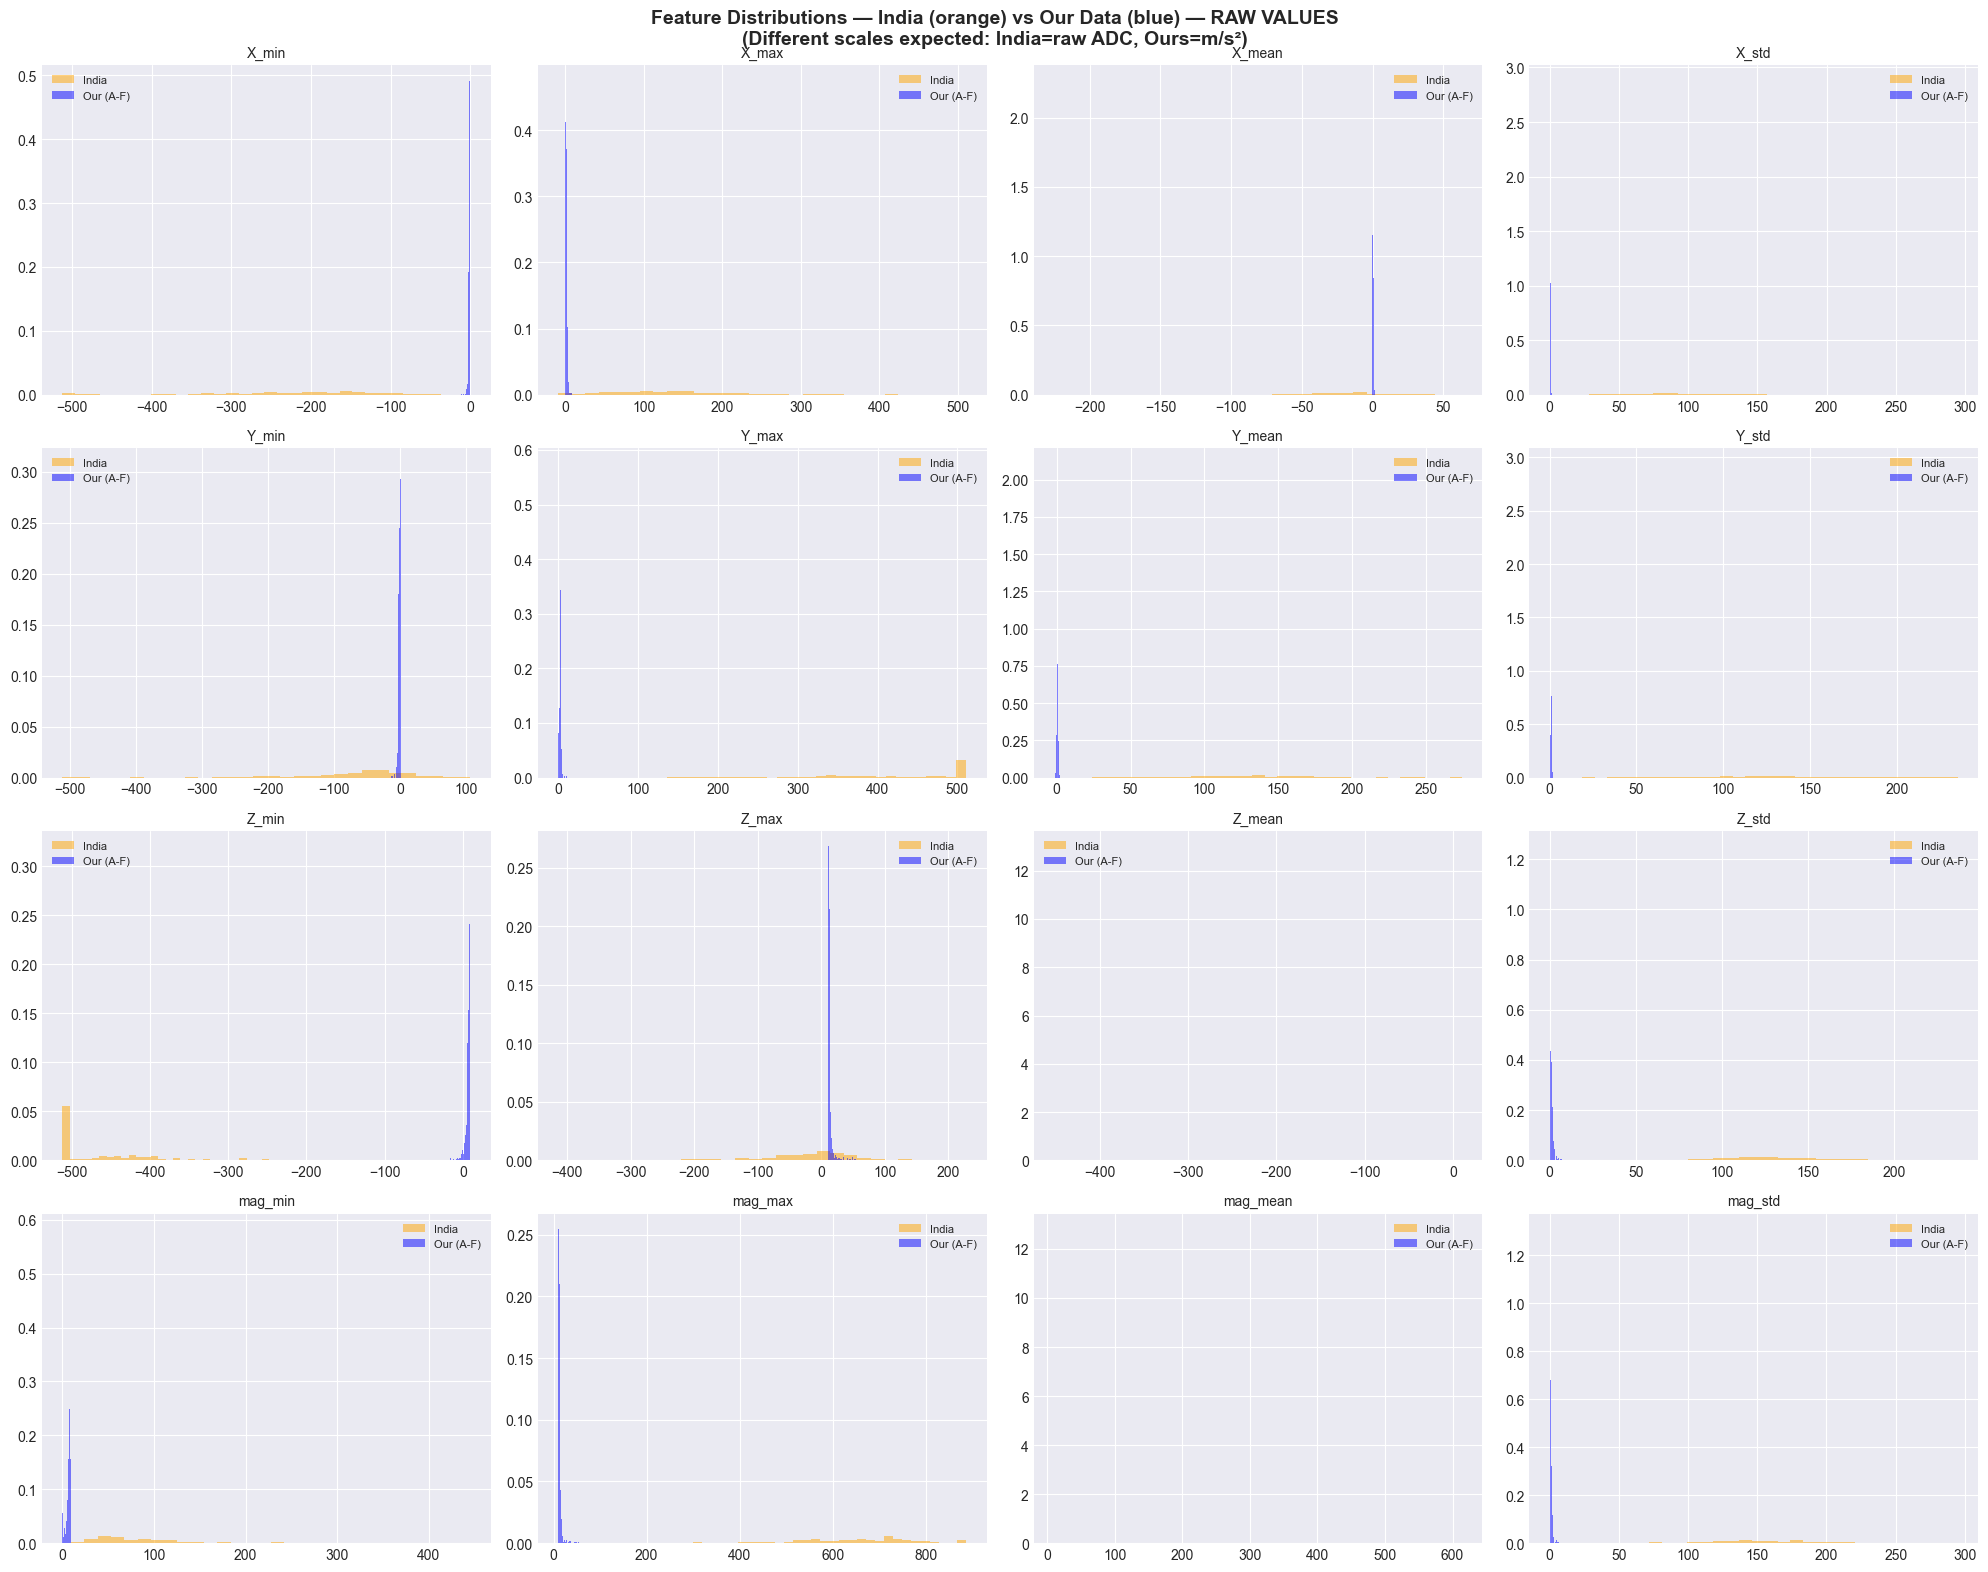

In [37]:
# ── 4b. Compare raw distributions (before normalization) ────────
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for ax, (ic, oc) in zip(axes.ravel(), zip(feature_cols, our_feature_cols)):
    india_vals = india_features[ic].dropna()
    our_vals = our_features[oc].dropna()
    
    ax.hist(india_vals, bins=30, alpha=0.5, color='orange', label='India', density=True)
    ax.hist(our_vals, bins=30, alpha=0.5, color='blue', label='Our (A-F)', density=True)
    ax.set_title(ic, fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions — India (orange) vs Our Data (blue) — RAW VALUES\n'
             '(Different scales expected: India=raw ADC, Ours=m/s²)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


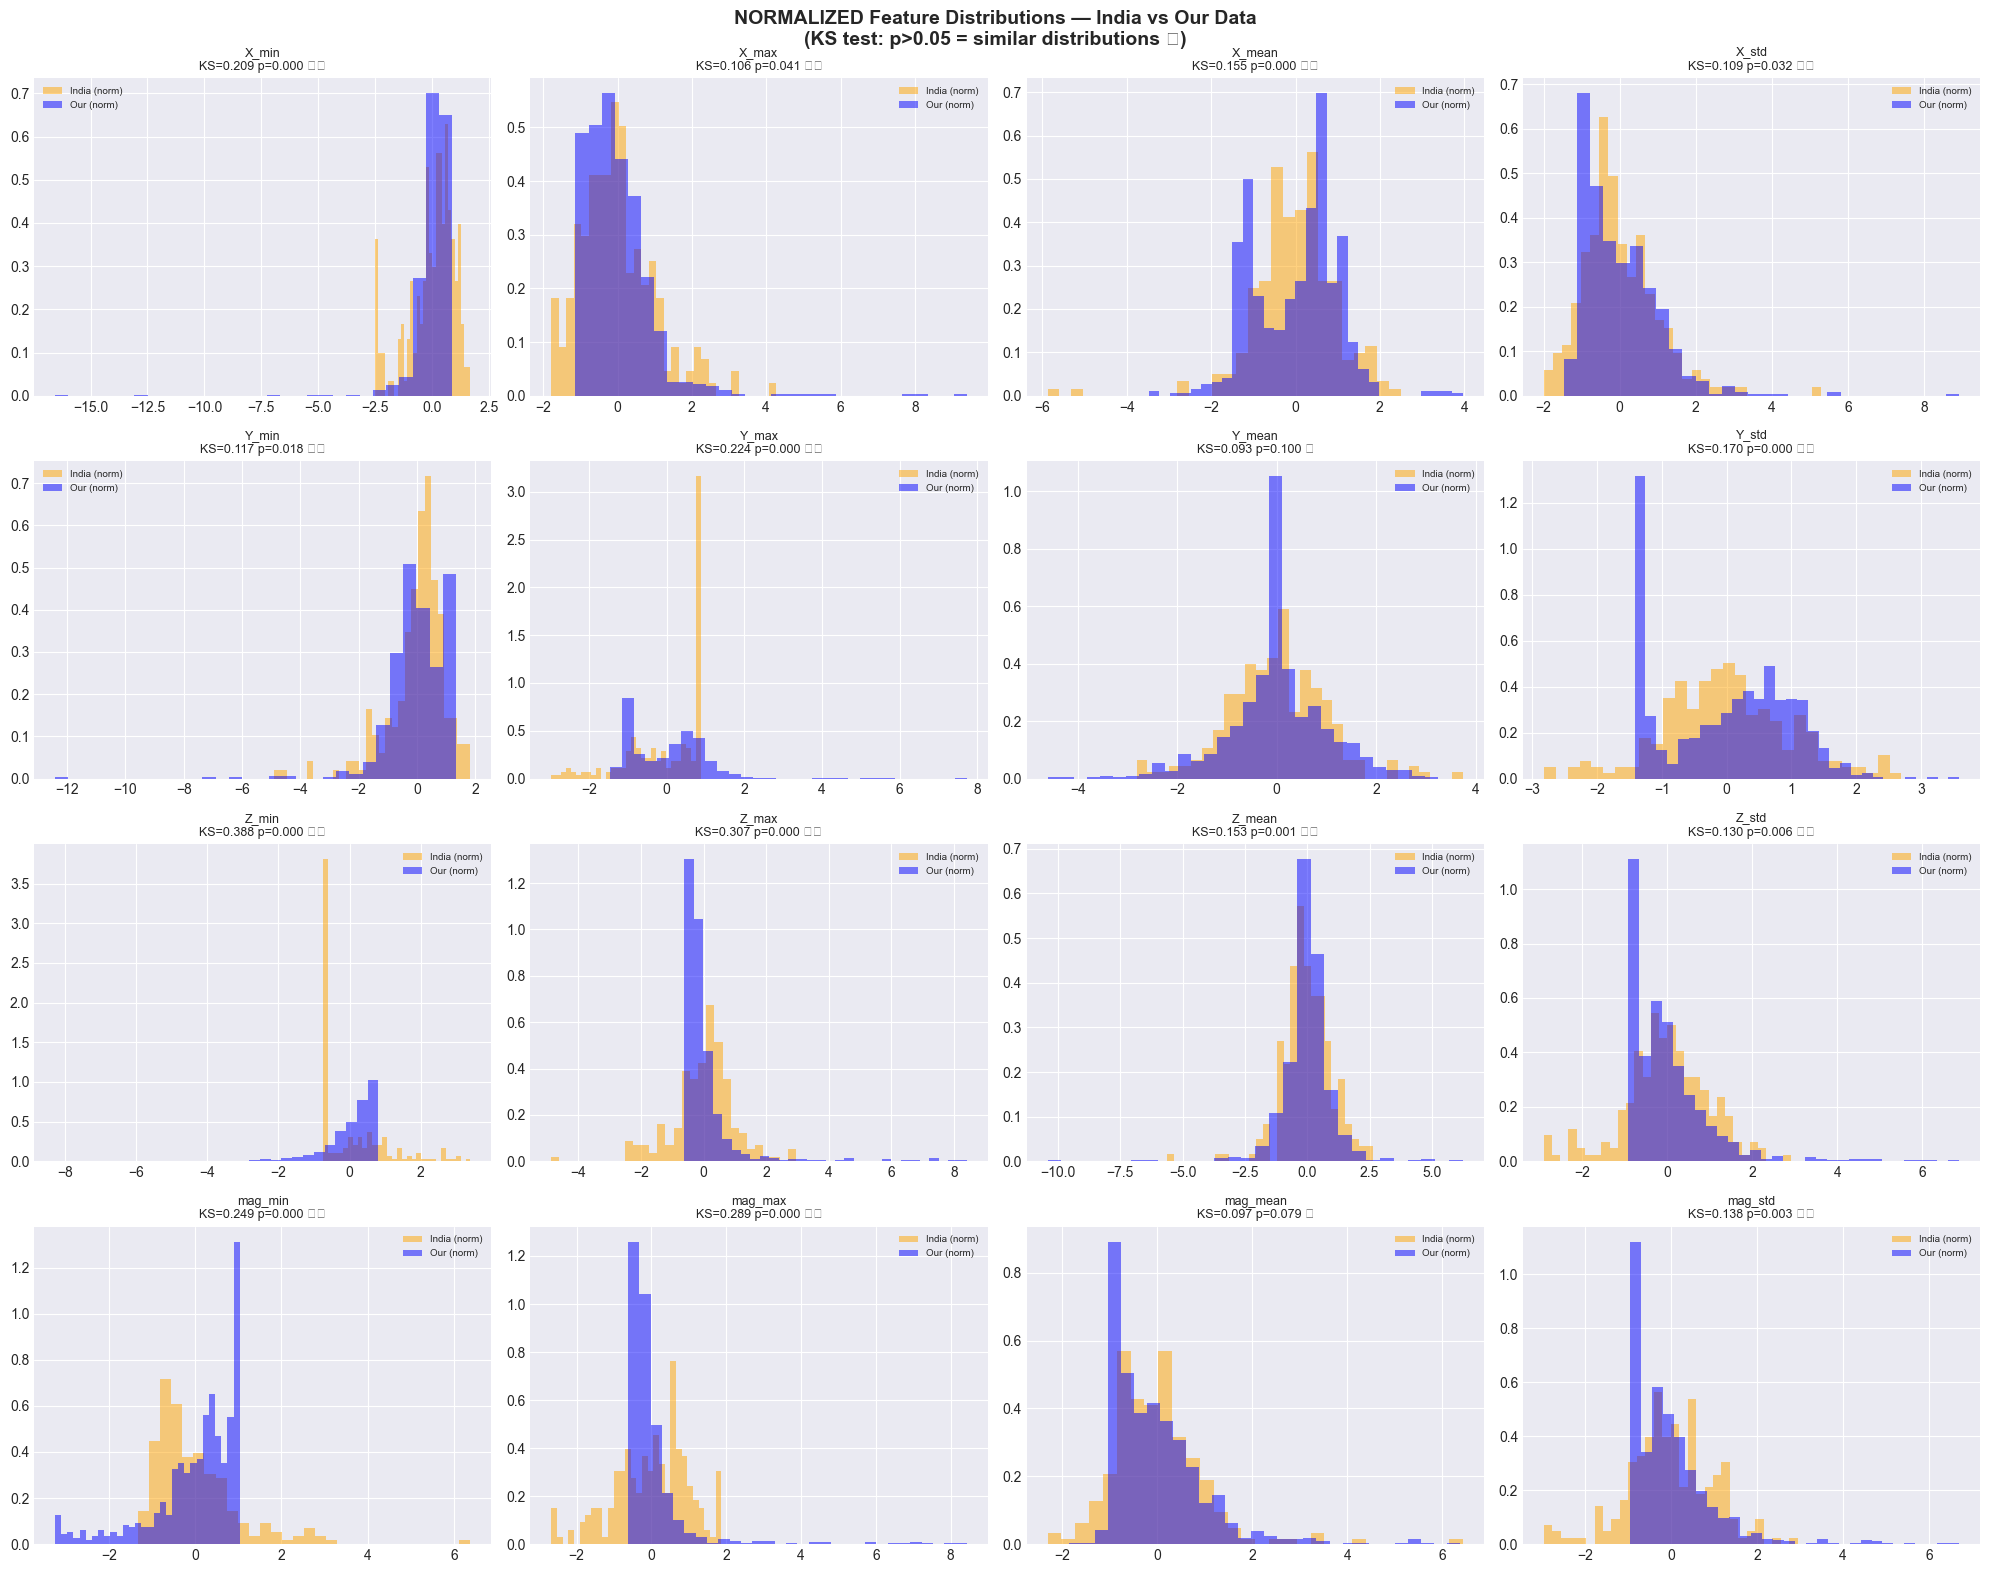


═══ KS Test Results: India vs Our Data (per feature) ═══
 feature  ks_stat      p_value  similar
   X_min 0.209189 5.536035e-07    False
   X_max 0.105991 4.069527e-02    False
  X_mean 0.155336 4.828529e-04    False
   X_std 0.109075 3.239310e-02    False
   Y_min 0.116738 1.788020e-02    False
   Y_max 0.223574 6.408069e-08    False
  Y_mean 0.092868 9.983562e-02     True
   Y_std 0.169721 9.650898e-05    False
   Z_min 0.388222 2.231112e-23    False
   Z_max 0.307476 1.106995e-14    False
  Z_mean 0.152776 6.349391e-04    False
   Z_std 0.130038 5.792827e-03    False
 mag_min 0.249038 9.789955e-10    False
 mag_max 0.289299 5.019260e-13    False
mag_mean 0.096542 7.854559e-02     True
 mag_std 0.138249 2.714297e-03    False

Similar features: 2/16
Mean KS statistic: 0.183


In [38]:
# ── 4c. Compare NORMALIZED distributions (what model sees) ──────
# Normalize both using their own Z-score (standard practice for domain comparison)
india_norm = StandardScaler().fit_transform(india_features.values)
our_norm = StandardScaler().fit_transform(our_features.values)

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
ks_results = []

for i, (ax, fc) in enumerate(zip(axes.ravel(), feature_cols)):
    ax.hist(india_norm[:, i], bins=30, alpha=0.5, color='orange', label='India (norm)', density=True)
    ax.hist(our_norm[:, i], bins=30, alpha=0.5, color='blue', label='Our (norm)', density=True)
    
    # KS test: are the distributions the same?
    ks_stat, ks_pval = stats.ks_2samp(india_norm[:, i], our_norm[:, i])
    ks_results.append({'feature': fc, 'ks_stat': ks_stat, 'p_value': ks_pval})
    
    status = '✅' if ks_pval > 0.05 else '⚠️'
    ax.set_title(f'{fc}\nKS={ks_stat:.3f} p={ks_pval:.3f} {status}', fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle('NORMALIZED Feature Distributions — India vs Our Data\n'
             '(KS test: p>0.05 = similar distributions ✅)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
ks_df = pd.DataFrame(ks_results)
ks_df['similar'] = ks_df['p_value'] > 0.05
print('\n═══ KS Test Results: India vs Our Data (per feature) ═══')
print(ks_df.to_string(index=False))
print(f'\nSimilar features: {ks_df["similar"].sum()}/{len(ks_df)}')
print(f'Mean KS statistic: {ks_df["ks_stat"].mean():.3f}')


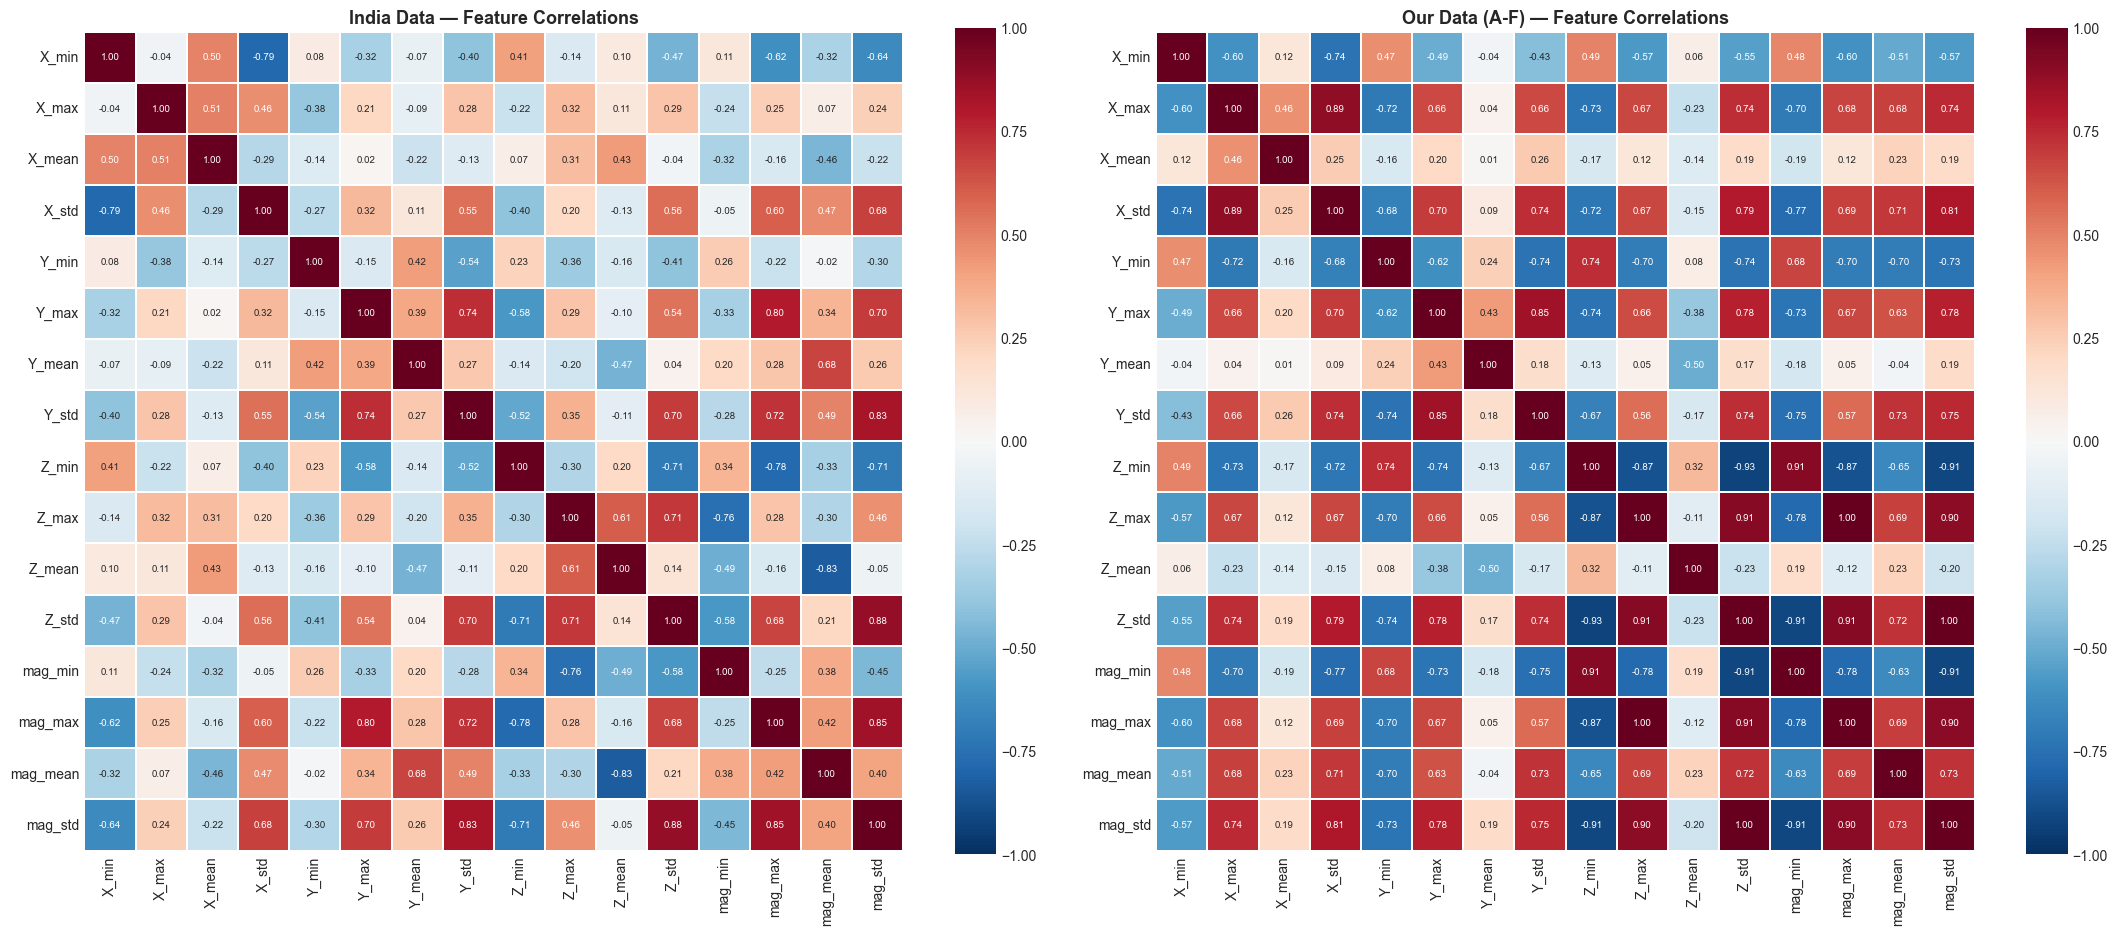


Correlation between the two correlation matrices: r=0.7813 (p=6.48e-26)
⚠️ MODERATE structural similarity — some differences in feature relationships


In [39]:
# ── 4d. Correlation matrices side by side ────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))

corr_india = pd.DataFrame(india_norm, columns=feature_cols).corr()
corr_ours = pd.DataFrame(our_norm, columns=feature_cols).corr()

sns.heatmap(corr_india, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax1, square=True, linewidths=0.3, vmin=-1, vmax=1, annot_kws={'size': 7})
ax1.set_title('India Data — Feature Correlations', fontsize=13, fontweight='bold')

sns.heatmap(corr_ours, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax2, square=True, linewidths=0.3, vmin=-1, vmax=1, annot_kws={'size': 7})
ax2.set_title('Our Data (A-F) — Feature Correlations', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Correlation between correlation matrices (how similar is the internal structure?)
corr_flat_india = corr_india.values[np.triu_indices(len(corr_india), k=1)]
corr_flat_ours = corr_ours.values[np.triu_indices(len(corr_ours), k=1)]
r, p = stats.pearsonr(corr_flat_india, corr_flat_ours)
print(f'\nCorrelation between the two correlation matrices: r={r:.4f} (p={p:.2e})')
if r > 0.8:
    print('✅ HIGH structural similarity — feature relationships are very similar')
elif r > 0.5:
    print('⚠️ MODERATE structural similarity — some differences in feature relationships')
else:
    print('❌ LOW structural similarity — different feature relationship patterns')


In [40]:
# ── 4e. Mean/Std comparison table ────────────────────────────────
comparison = []
for i, (ic, oc) in enumerate(zip(feature_cols, our_feature_cols)):
    india_vals = india_features[ic]
    our_vals = our_features[oc]
    comparison.append({
        'feature': ic,
        'india_mean': india_vals.mean(),
        'our_mean': our_vals.mean(),
        'india_std': india_vals.std(),
        'our_std': our_vals.std(),
        'india_median': india_vals.median(),
        'our_median': our_vals.median(),
    })

comp_df = pd.DataFrame(comparison)
print('═══ Raw Value Comparison (India vs Our Data) ═══')
print('Note: Different units — India=raw ADC values, Ours=m/s²')
print(comp_df.to_string(index=False))
print('\n✅ The raw values differ because of different sensor units.')
print('   After Z-score normalization, the MODEL sees comparable distributions.')
print('   The KS test results above show how well they match post-normalization.')


═══ Raw Value Comparison (India vs Our Data) ═══
Note: Different units — India=raw ADC values, Ours=m/s²
 feature  india_mean  our_mean  india_std  our_std  india_median  our_median
   X_min -228.419355 -0.987200 113.928073 1.425974   -206.000000   -0.774078
   X_max  144.087558  1.548991  86.036904 1.187829    133.000000    1.369891
  X_mean  -22.806492  0.286530  34.522024 0.307909    -20.200000    0.361358
   X_std   94.812075  0.433166  37.917788 0.236168     89.267720    0.380351
   Y_min  -62.400922 -1.413651  91.741891 1.654837    -43.000000   -1.345963
   Y_max  425.898618  2.230537  97.704528 1.460030    470.000000    2.349752
  Y_mean  131.516848  0.435107  38.240233 0.499711    131.769231    0.430324
   Y_std  129.370628  0.687910  39.303910 0.447885    127.911835    0.758668
   Z_min -461.419355  7.084817  68.556642 3.197447   -512.000000    7.934600
   Z_max  -14.562212 12.985638  82.368285 4.866427     -6.000000   11.953345
  Z_mean -218.632218  9.855661  41.584489 0.0520

## 5. Hybrid Approach — Pawar Model + V3 Logic

**Strategy:** The Pawar ANN is the **primary detector** (flags candidate pothole windows), then we apply the V3 pipeline to **refine and classify**:

1. **Pawar ANN** → probability score per 2-second window  
2. **V3 speed filtering** → reject low speed (<2 m/s), start/stop phases
3. **V3 multi-sensor features** → extract gyro peak/RMS, accel-X (braking), Z dip/bump direction from raw data
4. **V3 classification rules** → reclassify as Pothole / Road Bump / Speed Breaker / Hard Braking / etc.
5. **DBSCAN clustering** → merge nearby events by type
6. **Leaflet map** → v3-style color-coded markers with severity

This combines the **learned patterns** from Pawar's supervised model with **physics-based validation** from V3.


In [41]:
# ── 5a. Pawar predictions + V3 feature extraction ───────────────
from sklearn.cluster import DBSCAN

# ── Step 1: Run Pawar model on all windows ──────────────────────
our_scaler = StandardScaler()
our_X = our_all_windowed[our_feature_cols].values
our_X_scaled = our_scaler.fit_transform(our_X)

model.eval()
with torch.no_grad():
    our_X_t = torch.FloatTensor(our_X_scaled).to(device)
    our_probs = model(our_X_t).cpu().numpy()

our_preds = (our_probs >= 0.5).astype(int)
our_all_windowed = our_all_windowed.copy()
our_all_windowed['pawar_prob'] = our_probs
our_all_windowed['pawar_pred'] = our_preds

print(f'Pawar predictions: {our_preds.sum()} pothole / {len(our_preds)} total ({our_preds.mean()*100:.1f}%)')
for folder in folders:
    mask = our_all_windowed['route'] == folder
    n_ph = our_all_windowed.loc[mask, 'pawar_pred'].sum()
    print(f'  Route {folder}: {n_ph}/{mask.sum()} flagged ({n_ph/mask.sum()*100:.1f}%)')

# ── Step 2: Compute speed context (V3-style start/stop detection) ──
def compute_speed_context(gyro_df, loc_df, lookback_sec=3.0):
    """Interpolate GPS speed onto sensor timestamps + detect start/stop phases."""
    sensor_t = gyro_df['seconds_elapsed'].values.astype('float64')
    gps_t = loc_df['seconds_elapsed'].values.astype('float64')
    gps_speed = loc_df['speed'].values.astype('float64')
    interp_speed = np.interp(sensor_t, gps_t, gps_speed)
    
    is_start = np.zeros(len(sensor_t), dtype=bool)
    is_stop = np.zeros(len(sensor_t), dtype=bool)
    for i in range(len(sensor_t)):
        t_now = sensor_t[i]
        mask_back = (sensor_t >= t_now - lookback_sec) & (sensor_t <= t_now)
        if interp_speed[mask_back].min() < 1.0:
            is_start[i] = True
        mask_fwd = (sensor_t >= t_now) & (sensor_t <= t_now + lookback_sec)
        if interp_speed[mask_fwd].min() < 1.0:
            is_stop[i] = True
    
    return pd.DataFrame({
        'seconds_elapsed': sensor_t,
        'speed': interp_speed,
        'is_start_phase': is_start,
        'is_stop_phase': is_stop
    })

speed_contexts = {}
for folder in folders:
    d = our_data[folder]
    ctx = compute_speed_context(d['gyro'], d['location'])
    speed_contexts[folder] = ctx
    n_start = ctx['is_start_phase'].sum()
    n_stop = ctx['is_stop_phase'].sum()
    print(f'Route {folder}: speed {ctx["speed"].min()*3.6:.1f}-{ctx["speed"].max()*3.6:.1f} km/h, '
          f'start_phase={n_start}, stop_phase={n_stop}')

print('\nSpeed context computed for all routes.')


Pawar predictions: 373 pothole / 774 total (48.2%)
  Route A: 36/69 flagged (52.2%)
  Route B: 13/163 flagged (8.0%)
  Route C: 30/63 flagged (47.6%)
  Route D: 87/176 flagged (49.4%)
  Route E: 138/200 flagged (69.0%)
  Route F: 69/103 flagged (67.0%)
Route A: speed 0.0-40.6 km/h, start_phase=754, stop_phase=465
Route B: speed 0.0-28.0 km/h, start_phase=20711, stop_phase=20996
Route C: speed 5.2-64.4 km/h, start_phase=0, stop_phase=0
Route D: speed 0.0-44.2 km/h, start_phase=23057, stop_phase=23056
Route E: speed 0.0-45.1 km/h, start_phase=6252, stop_phase=5963
Route F: speed 0.0-46.0 km/h, start_phase=3721, stop_phase=3719

Speed context computed for all routes.


In [42]:
# ── 5b. Extract V3 features for Pawar-flagged windows ───────────
MIN_SPEED = 2.0  # m/s — reject below this

def extract_v3_features(our_windowed_route, route_data, speed_ctx, pawar_threshold=0.4):
    """
    For each window flagged by Pawar (prob >= threshold), extract V3-style
    multi-sensor features from the raw data and apply speed filtering.
    
    Using threshold=0.4 (slightly below 0.5) to catch borderline cases
    that V3 logic might still classify as something useful.
    """
    gyro_df = route_data['gyro']
    accel_df = route_data['accel']
    total_df = route_data['total']
    loc_df = route_data['location']
    
    # Pre-interpolate GPS onto total_accel timestamps
    loc_t = loc_df['seconds_elapsed'].values.astype('float64')
    loc_lat = loc_df['latitude'].values.astype('float64')
    loc_lon = loc_df['longitude'].values.astype('float64')
    
    events = []
    reject_counts = {'low_speed': 0, 'start_phase': 0, 'stop_phase': 0, 'below_threshold': 0}
    
    for _, win in our_windowed_route.iterrows():
        pawar_prob = win['pawar_prob']
        
        if pawar_prob < pawar_threshold:
            reject_counts['below_threshold'] += 1
            continue
        
        t_start = win['window_start']
        t_end = t_start + WINDOW_SEC
        mid = (t_start + t_end) / 2
        
        # ── Speed context filtering (V3-style) ─────────────────
        seg_ctx = speed_ctx[(speed_ctx['seconds_elapsed'] >= t_start) &
                            (speed_ctx['seconds_elapsed'] <= t_end)]
        if len(seg_ctx) == 0:
            idx = (speed_ctx['seconds_elapsed'] - mid).abs().idxmin()
            seg_ctx = speed_ctx.iloc[[idx]]
        
        avg_speed = float(seg_ctx['speed'].mean())
        any_start = bool(seg_ctx['is_start_phase'].any())
        any_stop = bool(seg_ctx['is_stop_phase'].any())
        
        if avg_speed < MIN_SPEED:
            reject_counts['low_speed'] += 1
            continue
        if any_start:
            reject_counts['start_phase'] += 1
            continue
        if any_stop:
            reject_counts['stop_phase'] += 1
            continue
        
        # ── TotalAccel Z features ──────────────────────────────
        t_mask = (total_df['seconds_elapsed'] >= t_start) & (total_df['seconds_elapsed'] < t_end)
        t_seg = total_df[t_mask]
        
        if len(t_seg) < 3:
            continue
        
        z_values = t_seg['z'].values.astype(float)
        z_min = float(z_values.min())
        z_max = float(z_values.max())
        z_mean = float(z_values.mean())
        z_std = float(z_values.std()) if len(z_values) > 1 else 0.0
        
        # Dip / bump from gravity baseline (9.81)
        dip_magnitude = max(0, 9.81 - z_min)    # how far below gravity
        bump_magnitude = max(0, z_max - 9.81)    # how far above gravity
        is_dip = dip_magnitude > bump_magnitude
        total_z_dev = float((t_seg['z'] - 9.81).abs().max())
        
        # ── Gyroscope features (V3 key discriminator) ──────────
        g_mask = (gyro_df['seconds_elapsed'] >= t_start) & (gyro_df['seconds_elapsed'] < t_end)
        g_seg = gyro_df[g_mask]
        if len(g_seg) > 0:
            gyro_mag = np.sqrt(g_seg['x']**2 + g_seg['y']**2 + g_seg['z']**2)
            gyro_peak = float(gyro_mag.max())
            gyro_rms = float(gyro_mag.mean())
        else:
            gyro_peak = gyro_rms = 0.0
        
        # ── Accelerometer X features (braking/acceleration) ────
        a_mask = (accel_df['seconds_elapsed'] >= t_start) & (accel_df['seconds_elapsed'] < t_end)
        a_seg = accel_df[a_mask]
        if len(a_seg) > 0:
            accel_x_min = float(a_seg['x'].min())
            accel_x_max = float(a_seg['x'].max())
            accel_x_peak = float(a_seg['x'].abs().max())
        else:
            accel_x_min = accel_x_max = accel_x_peak = 0.0
        
        # ── Braking before/after (V3 temporal context) ─────────
        pre_mask = (accel_df['seconds_elapsed'] >= t_start - 1.0) & (accel_df['seconds_elapsed'] < t_start)
        pre_seg = accel_df[pre_mask]
        braking_before = bool(len(pre_seg) > 0 and float(pre_seg['x'].min()) < -1.5)
        
        post_mask = (accel_df['seconds_elapsed'] > t_end) & (accel_df['seconds_elapsed'] <= t_end + 1.0)
        post_seg = accel_df[post_mask]
        braking_after = bool(len(post_seg) > 0 and float(post_seg['x'].min()) < -1.5)
        
        events.append({
            'window_start': t_start,
            'duration': WINDOW_SEC,
            'latitude': win['latitude'],
            'longitude': win['longitude'],
            'speed': avg_speed,
            'pawar_prob': pawar_prob,
            # Z-accel features
            'z_min': z_min, 'z_max': z_max, 'z_mean': z_mean, 'z_std': z_std,
            'dip_magnitude': dip_magnitude,
            'bump_magnitude': bump_magnitude,
            'is_dip': is_dip,
            'total_z_dev': total_z_dev,
            # Gyroscope
            'gyro_peak': gyro_peak, 'gyro_rms': gyro_rms,
            # Accelerometer X
            'accel_x_min': accel_x_min, 'accel_x_max': accel_x_max, 'accel_x_peak': accel_x_peak,
            # Context
            'braking_before': braking_before, 'braking_after': braking_after,
            'est_size_m': avg_speed * WINDOW_SEC,
        })
    
    return pd.DataFrame(events), reject_counts


# Process all routes
all_events = {}
for folder in folders:
    d = our_data[folder]
    route_win = our_all_windowed[our_all_windowed['route'] == folder]
    ctx = speed_contexts[folder]
    
    events_df, rejects = extract_v3_features(route_win, d, ctx, pawar_threshold=0.4)
    all_events[folder] = events_df
    
    n_flagged = (route_win['pawar_prob'] >= 0.4).sum()
    n_kept = len(events_df)
    print(f'\nRoute {folder}: {n_flagged} Pawar-flagged → {n_kept} after V3 filtering')
    print(f'  Rejected: low_speed={rejects["low_speed"]}, '
          f'start={rejects["start_phase"]}, stop={rejects["stop_phase"]}')

total_events = sum(len(d) for d in all_events.values())
print(f'\nTotal candidate events: {total_events}')



Route A: 38 Pawar-flagged → 36 after V3 filtering
  Rejected: low_speed=2, start=0, stop=0

Route B: 20 Pawar-flagged → 7 after V3 filtering
  Rejected: low_speed=12, start=1, stop=0

Route C: 30 Pawar-flagged → 30 after V3 filtering
  Rejected: low_speed=0, start=0, stop=0

Route D: 93 Pawar-flagged → 28 after V3 filtering
  Rejected: low_speed=64, start=1, stop=0

Route E: 141 Pawar-flagged → 112 after V3 filtering
  Rejected: low_speed=27, start=2, stop=0

Route F: 70 Pawar-flagged → 63 after V3 filtering
  Rejected: low_speed=5, start=2, stop=0

Total candidate events: 276


## 6. V3-Style Classification on Pawar-Flagged Events

**Hybrid logic:**
- **Pawar probability** as a confidence booster (higher prob → higher confidence)
- **V3 physics rules** for classification:
  - Pothole = Z dip (below gravity) + gyro confirms vehicle rocking
  - Road Bump = Z bump (above gravity) only
  - Speed Breaker = both dip AND bump + longer duration
  - Hard Braking = strong X-accel + low gyro + low Z deviation
  - Severity scaled by both Pawar confidence and V3 deviation metrics


In [43]:
# ── 6a. Hybrid classification (Pawar prob + V3 physics rules) ───

def classify_hybrid(row):
    """
    V3-style classification boosted by Pawar probability.
    Returns (event_type, severity, confidence).
    """
    pawar_p  = row['pawar_prob']
    z_min    = row['z_min']
    z_max    = row['z_max']
    z_std    = row['z_std']
    dip_mag  = row['dip_magnitude']
    bump_mag = row['bump_magnitude']
    is_dip   = row['is_dip']
    tz_dev   = row['total_z_dev']
    g_peak   = row['gyro_peak']
    g_rms    = row['gyro_rms']
    x_min    = row['accel_x_min']
    x_max    = row['accel_x_max']
    x_peak   = row['accel_x_peak']
    dur      = row['duration']
    speed    = row['speed']
    brk_bef  = row['braking_before']
    brk_aft  = row['braking_after']
    
    has_dip  = dip_mag > 0.5
    has_bump = bump_mag > 0.5

    # ═══════════════════════════════════════════════════════════
    # 1. HARD BRAKING / ACCELERATION
    #    Strong X-accel + low gyro + low Z deviation = driver, not road
    # ═══════════════════════════════════════════════════════════
    if x_peak > 2.0 and g_peak < 0.3 and tz_dev < 2.0:
        severity = min(10, x_peak * 1.5)
        if x_min < -2.5:
            return 'Hard Braking', severity, 0.80
        elif x_max > 2.5:
            return 'Acceleration', severity, 0.75
        lbl = 'Hard Braking' if abs(x_min) > x_max else 'Acceleration'
        return lbl, severity, 0.70

    # Braking context before + low vertical = braking vibration
    if brk_bef and g_peak < 0.3 and tz_dev < 2.0:
        severity = min(10, x_peak * 1.2)
        return 'Hard Braking', severity, 0.65

    # ═══════════════════════════════════════════════════════════
    # 2. ROAD BUMP: Z went UP only, not down
    # ═══════════════════════════════════════════════════════════
    if has_bump and not has_dip:
        severity = min(10, bump_mag * 1.5)
        if dur > 0.15 and bump_mag > 2.0:
            return 'Speed Bump', severity, 0.70
        return 'Road Bump', severity, 0.50

    # ═══════════════════════════════════════════════════════════
    # 3. SPEED BUMP: both dip AND bump + longer duration
    # ═══════════════════════════════════════════════════════════
    if has_dip and has_bump and g_peak < 0.8:
        total_osc = dip_mag + bump_mag
        if total_osc > 3.0 or (bump_mag > dip_mag * 0.5 and bump_mag > 1.0):
            severity = min(10, total_osc * 0.8)
            return 'Speed Bump', severity, 0.65

    # ═══════════════════════════════════════════════════════════
    # 4. POTHOLE: Z dip + gyro confirms + Pawar boosts confidence
    #    This is the KEY hybrid logic:
    #    - V3 physics (dip + gyro) for classification
    #    - Pawar probability for confidence boosting
    # ═══════════════════════════════════════════════════════════
    if has_dip:
        # Base severity from V3 features
        severity = min(10, dip_mag * 1.2 + g_peak * 2.0 + pawar_p * 1.5)
        
        # High gyro = confirmed pothole (vehicle rocked)
        if g_peak > 0.3:
            confidence = min(0.95, 0.55 + dip_mag * 0.05 + g_peak * 0.15 + pawar_p * 0.15)
            if brk_aft:
                confidence = min(1.0, confidence + 0.05)
            return 'Pothole', severity, confidence
        
        # Pawar is very confident + decent dip = trust the model
        if pawar_p > 0.7 and dip_mag > 0.8:
            confidence = min(0.85, 0.5 + pawar_p * 0.2 + dip_mag * 0.05)
            return 'Pothole', severity, confidence
        
        # Large Z deviation alone (deep dip)
        if dip_mag > 3.0:
            return 'Pothole', severity, 0.55
        
        # Moderate dip + some gyro
        if dip_mag > 1.5 and g_peak > 0.15:
            return 'Pothole', severity, 0.50
        
        # Small dip — rough patch
        return 'Rough Patch', min(5, dip_mag * 0.8), 0.30

    # ═══════════════════════════════════════════════════════════
    # 5. PAWAR-ONLY: High Pawar probability but no clear V3 signal
    #    Trust the model if probability is very high
    # ═══════════════════════════════════════════════════════════
    if pawar_p > 0.8:
        severity = min(6, tz_dev * 0.8 + pawar_p * 2)
        return 'Possible Pothole', severity, 0.40

    # ═══════════════════════════════════════════════════════════
    # 6. MINOR ANOMALY
    # ═══════════════════════════════════════════════════════════
    severity = min(4, tz_dev * 0.5)
    return 'Minor Anomaly', severity, 0.20


# Apply classification
for folder in folders:
    df = all_events[folder]
    if len(df) == 0:
        continue
    classified = df.apply(classify_hybrid, axis=1, result_type='expand')
    df['event_type'] = classified[0]
    df['severity'] = classified[1].astype('float32')
    df['confidence'] = classified[2].astype('float32')
    df['route'] = folder
    all_events[folder] = df

# Show distribution
for folder in folders:
    df = all_events[folder]
    if len(df) == 0:
        print(f'\nRoute {folder}: no events after filtering')
        continue
    print(f'\nRoute {folder} ({len(df)} events):')
    print(df['event_type'].value_counts().to_string())
    for etype in ['Pothole', 'Hard Braking', 'Speed Bump']:
        sub = df[df['event_type'] == etype]
        if len(sub) > 0:
            print(f'  → {etype}: {len(sub)} (avg sev: {sub["severity"].mean():.1f}, '
                  f'avg conf: {sub["confidence"].mean():.2f}, '
                  f'avg gyro: {sub["gyro_peak"].mean():.3f}, '
                  f'avg pawar: {sub["pawar_prob"].mean():.2f})')


Route A (36 events):
event_type
Speed Bump      33
Pothole          2
Hard Braking     1
  → Pothole: 2 (avg sev: 10.0, avg conf: 0.95, avg gyro: 1.243, avg pawar: 1.00)
  → Hard Braking: 1 (avg sev: 1.7, avg conf: 0.65, avg gyro: 0.208, avg pawar: 0.94)
  → Speed Bump: 33 (avg sev: 5.3, avg conf: 0.65, avg gyro: 0.248, avg pawar: 0.82)

Route B (7 events):
event_type
Speed Bump    7
  → Speed Bump: 7 (avg sev: 3.9, avg conf: 0.65, avg gyro: 0.119, avg pawar: 0.75)

Route C (30 events):
event_type
Speed Bump    27
Pothole        3
  → Pothole: 3 (avg sev: 10.0, avg conf: 0.98, avg gyro: 1.845, avg pawar: 1.00)
  → Speed Bump: 27 (avg sev: 6.8, avg conf: 0.65, avg gyro: 0.310, avg pawar: 0.95)

Route D (28 events):
event_type
Speed Bump    26
Pothole        2
  → Pothole: 2 (avg sev: 9.7, avg conf: 0.98, avg gyro: 1.703, avg pawar: 1.00)
  → Speed Bump: 26 (avg sev: 6.0, avg conf: 0.65, avg gyro: 0.303, avg pawar: 0.90)

Route E (112 events):
event_type
Speed Bump    95
Pothole       1

In [44]:
# ── 6b. DBSCAN Clustering & Leaflet Map ───
from sklearn.cluster import DBSCAN
import folium

# Combine all events
all_classified = pd.concat([all_events[f] for f in folders if len(all_events[f]) > 0], ignore_index=True)

# Filter: keep interesting events only (skip Minor Anomaly)
interesting = all_classified[all_classified['event_type'] != 'Minor Anomaly'].copy()
print(f'Total interesting events: {len(interesting)} (dropped {len(all_classified)-len(interesting)} Minor Anomalies)')
print(f'Columns available: {list(interesting.columns)}')

# ── DBSCAN: cluster by event type separately ──
cluster_id = 0
interesting['cluster'] = -1

for etype in interesting['event_type'].unique():
    mask = interesting['event_type'] == etype
    sub = interesting[mask]
    if len(sub) < 2:
        interesting.loc[mask, 'cluster'] = cluster_id
        cluster_id += 1
        continue
    
    coords_rad = np.radians(sub[['latitude', 'longitude']].values)
    db = DBSCAN(eps=20/6371000, min_samples=1, metric='haversine').fit(coords_rad)
    labels = db.labels_
    interesting.loc[mask, 'cluster'] = labels + cluster_id
    cluster_id += labels.max() + 2

# ── Build V3-style Folium map ──
center_lat = interesting['latitude'].mean()
center_lon = interesting['longitude'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=14,
               tiles='CartoDB positron')

# Color map — all event types plotted
color_map = {
    'Pothole': 'red',
    'Road Bump': 'green',
    'Speed Bump': '#DAA520',     # goldenrod
    'Hard Braking': 'brown',
    'Rough Patch': '#8B4513',    # saddle brown
    'Acceleration': 'blue',
    'Possible Pothole': 'orange',
}

# Route polylines (Location.csv columns are lowercase: latitude, longitude)
route_colors = {'A': '#e6194b', 'B': '#3cb44b', 'C': '#4363d8',
                'D': '#f58231', 'E': '#911eb4', 'F': '#42d4f4'}
for folder in folders:
    if folder not in our_data:
        continue
    loc_df = our_data[folder]['location'].dropna(subset=['latitude', 'longitude'])
    if len(loc_df) < 2:
        continue
    pts = loc_df[['latitude', 'longitude']].values.tolist()
    folium.PolyLine(pts, color=route_colors.get(folder, '#999999'),
                    weight=3, opacity=0.5,
                    tooltip=f'Route {folder}').add_to(m)

# Event markers — ALL event types plotted on map
for _, row in interesting.iterrows():
    etype = row['event_type']
    color = color_map.get(etype, 'gray')
    radius = max(4, min(12, row['severity'] * 1.2))
    
    popup_html = f"""
    <div style="font-family:monospace; width:220px">
        <b style="color:{color}">{etype}</b><br>
        Route: {row['route']}<br>
        Severity: {row['severity']:.1f}/10<br>
        Confidence: {row['confidence']:.0%}<br>
        Pawar prob: {row['pawar_prob']:.2f}<br>
        Speed: {row['speed']:.1f} m/s<br>
        Gyro peak: {row['gyro_peak']:.3f} rad/s<br>
        Z dip: {row['dip_magnitude']:.2f} m/s²<br>
        Z bump: {row['bump_magnitude']:.2f} m/s²<br>
        X peak: {row['accel_x_peak']:.2f} m/s²
    </div>
    """
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{etype} (sev: {row['severity']:.1f})"
    ).add_to(m)

# Legend — shows all event types
legend_html = '''
<div style="position:fixed; top:10px; right:10px; width:180px;
     background:white; border:2px solid gray; z-index:9999; padding:10px;
     font-size:12px; border-radius:5px; box-shadow:2px 2px 6px rgba(0,0,0,0.3);">
<b>Hybrid Pawar+V3</b><br>
'''
for label, col in color_map.items():
    legend_html += f'<span style="color:{col}; font-size:16px;">●</span> {label}<br>'
legend_html += '<br><b>Routes:</b><br>'
for f, c in route_colors.items():
    legend_html += f'<span style="color:{c};">━━</span> Route {f}<br>'
legend_html += '</div>'
m.get_root().html.add_child(folium.Element(legend_html))

# Save
map_path = os.path.join('.', 'hybrid_pawar_v3_map.html')
m.save(map_path)
print(f'\nMap saved to: {map_path}')
print(f'Events on map: {len(interesting)}')
print(f'\nEvent type distribution on map:')
print(interesting['event_type'].value_counts().to_string())
m

Total interesting events: 276 (dropped 0 Minor Anomalies)
Columns available: ['window_start', 'duration', 'latitude', 'longitude', 'speed', 'pawar_prob', 'z_min', 'z_max', 'z_mean', 'z_std', 'dip_magnitude', 'bump_magnitude', 'is_dip', 'total_z_dev', 'gyro_peak', 'gyro_rms', 'accel_x_min', 'accel_x_max', 'accel_x_peak', 'braking_before', 'braking_after', 'est_size_m', 'event_type', 'severity', 'confidence', 'route']

Map saved to: .\hybrid_pawar_v3_map.html
Events on map: 276

Event type distribution on map:
event_type
Speed Bump      246
Pothole          29
Hard Braking      1


## 7. Summary & Export

The hybrid Pawar + V3 pipeline:
1. **Pawar ANN** flags candidate windows (prob ≥ 0.4)
2. **Speed filtering** removes events at < 2 m/s & start/stop phases
3. **V3 feature extraction** computes gyro peak, Z dip/bump, accel-X, braking context
4. **V3 classification rules** assign event types: Pothole, Road Bump, Speed Bump, Hard Braking, Acceleration, Rough Patch, Possible Pothole
5. **DBSCAN clustering** groups nearby events by type
6. **Severity & confidence** combine Pawar probability with V3 physics magnitudes

In [45]:
# ── 7a. Export CSV & Summary ───

# Save classified events
csv_path = os.path.join('.', 'hybrid_events_all_routes.csv')
export_cols = ['route', 'latitude', 'longitude', 'speed', 'event_type', 'severity',
               'confidence', 'pawar_prob', 'gyro_peak', 'dip_magnitude',
               'bump_magnitude', 'accel_x_peak', 'total_z_dev', 'cluster']
interesting[export_cols].to_csv(csv_path, index=False)
print(f'Exported {len(interesting)} events to: {csv_path}')

# Summary table
print('\n' + '='*60)
print('HYBRID PAWAR + V3 DETECTION SUMMARY')
print('='*60)
for folder in folders:
    df = all_events[folder]
    if len(df) == 0:
        print(f'\nRoute {folder}: no candidate windows')
        continue
    keep = df[df['event_type'] != 'Minor Anomaly']
    print(f'\nRoute {folder}:')
    print(f'  Pawar candidates : {len(df)}')
    print(f'  After V3 classify: {len(keep)} meaningful events')
    for etype in keep['event_type'].unique():
        sub = keep[keep['event_type'] == etype]
        print(f'    {etype:20s}: {len(sub):3d}  '
              f'avg sev={sub["severity"].mean():.1f}  '
              f'avg conf={sub["confidence"].mean():.0%}')

# Overall
print(f'\n{"─"*60}')
print(f'TOTAL on map: {len(interesting)} events')
for etype in interesting['event_type'].value_counts().index:
    cnt = (interesting['event_type'] == etype).sum()
    sev = interesting.loc[interesting['event_type'] == etype, 'severity'].mean()
    print(f'  {etype:20s}: {cnt:3d}  avg severity = {sev:.1f}/10')

Exported 276 events to: .\hybrid_events_all_routes.csv

HYBRID PAWAR + V3 DETECTION SUMMARY

Route A:
  Pawar candidates : 36
  After V3 classify: 36 meaningful events
    Speed Bump          :  33  avg sev=5.3  avg conf=65%
    Pothole             :   2  avg sev=10.0  avg conf=95%
    Hard Braking        :   1  avg sev=1.7  avg conf=65%

Route B:
  Pawar candidates : 7
  After V3 classify: 7 meaningful events
    Speed Bump          :   7  avg sev=3.9  avg conf=65%

Route C:
  Pawar candidates : 30
  After V3 classify: 30 meaningful events
    Speed Bump          :  27  avg sev=6.8  avg conf=65%
    Pothole             :   3  avg sev=10.0  avg conf=98%

Route D:
  Pawar candidates : 28
  After V3 classify: 28 meaningful events
    Speed Bump          :  26  avg sev=6.0  avg conf=65%
    Pothole             :   2  avg sev=9.7  avg conf=98%

Route E:
  Pawar candidates : 112
  After V3 classify: 112 meaningful events
    Speed Bump          :  95  avg sev=5.7  avg conf=65%
    Pothole  